In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import os, random, math
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from PIL import Image
from pathlib import Path

FOLDER_PATH = "/content/drive/MyDrive/colab/emoji"
CSV_PATH = f"{FOLDER_PATH}/emoji_dataset.csv"

WORK_DIR = "/content/emoji_project"
AUG_DIR = f"{WORK_DIR}/aug_images"
os.makedirs(AUG_DIR, exist_ok=True)
OUT_DIR = f"{WORK_DIR}/prepared"

In [3]:
df = pd.read_csv(CSV_PATH)
print("Rows:", len(df))
print("Columns:", list(df.columns))
df.head(5)

Rows: 5042
Columns: ['SI', 'Emoji Unicode', 'Emoji Name', 'Emoji Character']


,SI,Emoji Unicode,Emoji Name,Emoji Character
0,1,U+1F947,:1st_place_medal:,🥇
1,2,U+1F948,:2nd_place_medal:,🥈
2,3,U+1F949,:3rd_place_medal:,🥉
3,4,U+1F18E,:AB_button_(blood_type):,🆎
4,5,U+1F3E7,:ATM_sign:,🏧


In [4]:
pairs = []

for _, row in df.iterrows():
    folder = str(row["Emoji Unicode"]).strip()
    img_path = os.path.join(FOLDER_PATH, folder, "emoji.png")
    if os.path.exists(img_path):
        text = str(row["Emoji Name"]).strip()
        pairs.append((img_path, text))

print(f"Collected {len(pairs)} pairs out of {len(df)}")

Collected 4144 pairs out of 5042


Аугментация картинок

In [5]:
def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def auto_crop_to_content(gray, pad=8):
    thr = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY_INV)[1]
    ys, xs = np.where(thr > 0)
    if len(xs) == 0 or len(ys) == 0:
        return gray
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
    x1 = min(gray.shape[1]-1, x1 + pad); y1 = min(gray.shape[0]-1, y1 + pad)
    return gray[y0:y1+1, x0:x1+1]

def random_affine(img, max_rot=25, max_scale=0.20, max_shift=0.12):
    h, w = img.shape[:2]
    ang = random.uniform(-max_rot, max_rot)
    sc = 1.0 + random.uniform(-max_scale, max_scale)
    tx = random.uniform(-max_shift, max_shift) * w
    ty = random.uniform(-max_shift, max_shift) * h
    M = cv2.getRotationMatrix2D((w/2, h/2), ang, sc)
    M[:, 2] += (tx, ty)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=255)

def edges_sketch(gray):
    g = cv2.GaussianBlur(gray, (5,5), 0)
    e = cv2.Canny(g, 40, 120)
    out = 255 - e
    return out

def thicken_or_thin(lines):
    inv = 255 - lines
    k = random.choice([1, 2, 3])
    kernel = np.ones((k, k), np.uint8)
    if random.random() < 0.5:
        inv2 = cv2.dilate(inv, kernel, iterations=1)
    else:
        inv2 = cv2.erode(inv, kernel, iterations=1)
    return 255 - inv2

def add_noise(gray, amount=0.02):
    g = gray.astype(np.float32)
    n = np.random.randn(*g.shape) * 20.0
    mask = (np.random.rand(*g.shape) < amount).astype(np.float32)
    g2 = g + n * mask
    return np.clip(g2, 0, 255).astype(np.uint8)

def random_breaks(lines, p=0.015):
    out = lines.copy()
    black = out < 80
    drop = (np.random.rand(*out.shape) < p) & black
    out[drop] = 255
    return out

def pad_to_square(gray, size=224, pad_val=255):
    h, w = gray.shape
    m = max(h, w)
    canvas = np.full((m, m), pad_val, dtype=np.uint8)
    y0 = (m - h) // 2
    x0 = (m - w) // 2
    canvas[y0:y0+h, x0:x0+w] = gray
    return cv2.resize(canvas, (size, size), interpolation=cv2.INTER_AREA)

In [6]:
def make_augmented_variants(image_path, n=8, out_size=256):
    rgb = np.array(Image.open(image_path).convert("RGB"))
    gray = to_gray(rgb)
    gray = auto_crop_to_content(gray, pad=10)

    variants = []
    for _ in range(n):
        g = gray.copy()
        g = random_affine(g)

        if random.random() < 0.9:
            g = edges_sketch(g)

        if random.random() < 0.9:
            g = thicken_or_thin(g)

        if random.random() < 0.7:
            g = random_breaks(g, p=random.uniform(0.008, 0.04))

        if random.random() < 0.7:
            g = add_noise(g, amount=random.uniform(0.005, 0.03))

        g = pad_to_square(g, size=out_size)
        variants.append(g)
    return variants

In [7]:
from tqdm.auto import tqdm
import shutil

if os.path.exists(AUG_DIR):
    shutil.rmtree(AUG_DIR)
os.makedirs(AUG_DIR, exist_ok=True)

AUG_PER_IMAGE = 8

out_rows = []

for i, (img_path, text) in enumerate(tqdm(pairs, desc="Augmenting images")):
    out_rows.append((img_path, text))

    base = Path(img_path).parent.name
    variants = make_augmented_variants(img_path, n=AUG_PER_IMAGE, out_size=256)

    for j, g in enumerate(variants):
        out_name = f"{base}__aug{j:02d}__{i:05d}.png"
        out_path = os.path.join(AUG_DIR, out_name)
        cv2.imwrite(out_path, g)
        out_rows.append((out_path, text))

aug_df = pd.DataFrame(out_rows, columns=["image_path", "text"])
aug_pairs = list(zip(aug_df["image_path"].tolist(), aug_df["text"].tolist()))
out_csv = f"{WORK_DIR}/prepared/train_aug_256.csv"
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
aug_df.to_csv(out_csv, index=False)

print("Saved:", out_csv)
print("Rows:", len(aug_df))
print(aug_df.head())

Augmenting images:   0%|          | 0/4144 [00:00<?, ?it/s]

Saved: /content/emoji_project/prepared/train_aug_256.csv
Rows: 37296
                                          image_path                      text
0  /content/drive/MyDrive/colab/emoji/U+1F18E/emo...  :AB_button_(blood_type):
1  /content/emoji_project/aug_images/U+1F18E__aug...  :AB_button_(blood_type):
2  /content/emoji_project/aug_images/U+1F18E__aug...  :AB_button_(blood_type):
3  /content/emoji_project/aug_images/U+1F18E__aug...  :AB_button_(blood_type):
4  /content/emoji_project/aug_images/U+1F18E__aug...  :AB_button_(blood_type):


Скачиваем, если уже есть

In [7]:
AUG_CSV = f"{WORK_DIR}/prepared/train_aug_256.csv"
assert os.path.exists(AUG_CSV), f"Not found: {AUG_CSV}"

aug_df = pd.read_csv(AUG_CSV)
aug_pairs = list(zip(aug_df["image_path"].tolist(), aug_df["text"].tolist()))

In [8]:
from sklearn.model_selection import train_test_split

train_pairs, val_pairs = train_test_split(
    aug_pairs,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

Загрузим модель и напишем токенизатор для картинок и Emoji Name

In [9]:
!pip -q install open_clip_torch timm pillow

In [10]:
import torch
import open_clip
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [12]:
model_name = "ViT-B-32"
pretrained = "openai"

model, _, preprocess = open_clip.create_model_and_transforms(
    model_name=model_name,
    pretrained=pretrained,
    device=device
)
tokenizer = open_clip.get_tokenizer(model_name)

model.eval()
print("Loaded:", model_name, pretrained, "on", device)

Loaded: ViT-B-32 openai on cuda


In [13]:
train_texts = [t for _, t in train_pairs]
val_texts   = [t for _, t in val_pairs]

train_tokens = tokenizer(train_texts)
val_tokens   = tokenizer(val_texts)

print(train_tokens.shape)
print(val_tokens.shape)

torch.Size([33566, 77])
torch.Size([3730, 77])


Датасет+Даталоадер

In [14]:
class EmojiAugDataset(Dataset):
    def __init__(self, pairs, text_tokens, preprocess):
        assert len(pairs) == text_tokens.shape[0]
        self.pairs = pairs
        self.text_tokens = text_tokens
        self.preprocess = preprocess

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, _ = self.pairs[idx]
        img = Image.open(img_path).convert("RGB")
        img = self.preprocess(img)
        txt = self.text_tokens[idx]
        return img, txt


train_dataset = EmojiAugDataset(train_pairs, train_tokens, preprocess)
val_dataset   = EmojiAugDataset(val_pairs, val_tokens, preprocess)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [15]:
model.train()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=0.2
)

use_amp = (device == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=use_amp) if use_amp else None

Код для одной эпохи

In [16]:
def clip_loss(image_features, text_features, logit_scale):
    image_features = F.normalize(image_features, dim=-1)
    text_features  = F.normalize(text_features, dim=-1)

    logits_per_image = logit_scale * image_features @ text_features.t()
    logits_per_text  = logits_per_image.t()

    batch_size = image_features.size(0)
    labels = torch.arange(batch_size, device=image_features.device)

    loss_i = F.cross_entropy(logits_per_image, labels)
    loss_t = F.cross_entropy(logits_per_text, labels)
    return (loss_i + loss_t) / 2

In [21]:
EPOCHS = 10

for epoch in range(EPOCHS):
    # ----- TRAIN -----
    model.train()
    train_loss = 0

    for images, txt_tokens_batch in tqdm(train_loader, desc=f"Train {epoch+1}"):

        images = images.to(device)
        txt_tokens_batch = txt_tokens_batch.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device, enabled=(device=="cuda")):
            img_f = model.encode_image(images)
            txt_f = model.encode_text(txt_tokens_batch)
            logit_scale = model.logit_scale.exp()
            loss = clip_loss(img_f, txt_f, logit_scale)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ----- VALIDATION -----
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, txt_tokens_batch in tqdm(val_loader, desc="Val"):

            images = images.to(device)
            txt_tokens_batch = txt_tokens_batch.to(device)

            img_f = model.encode_image(images)
            txt_f = model.encode_text(txt_tokens_batch)
            logit_scale = model.logit_scale.exp()

            loss = clip_loss(img_f, txt_f, logit_scale)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch+1}")
    print("Train loss:", train_loss)
    print("Val loss:", val_loss)

    epoch_dir = os.path.join(WORK_DIR, f"epoch_{epoch+1:02d}")
    os.makedirs(epoch_dir, exist_ok=True)

    CKPT_PATH = os.path.join(epoch_dir, "clip_finetuned.pt")

    torch.save(
        {
            "epoch": epoch + 1,
            "model": model.state_dict(),
            "model_name": model_name,
            "pretrained": pretrained,
        },
        CKPT_PATH
    )

    print("Saved:", CKPT_PATH)

Train 1:   0%|          | 0/262 [00:00<?, ?it/s]

Val:   0%|          | 0/30 [00:00<?, ?it/s]


Epoch 1
Train loss: 2.377878458900306
Val loss: 1.9690951069196065
Saved: /content/emoji_project/epoch_01/clip_finetuned.pt


Train 2:   0%|          | 0/262 [00:00<?, ?it/s]

Val:   0%|          | 0/30 [00:00<?, ?it/s]

...

Val:   0%|          | 0/30 [00:00<?, ?it/s]


Epoch 9
Train loss: 1.341928856745931
Val loss: 1.9450072964032492
Saved: /content/emoji_project/epoch_09/clip_finetuned.pt


Train 10:   0%|          | 0/262 [00:00<?, ?it/s]

Val:   0%|          | 0/30 [00:00<?, ?it/s]


Epoch 10
Train loss: 1.2443583107176628
Val loss: 2.1362293561299643
Saved: /content/emoji_project/epoch_10/clip_finetuned.pt


После 4ой эпохи Val loss растёт, Train loss падает. Это переобучение. Лучшая модель после 4ой эпохи. Загружу её

In [24]:
checkpoint = torch.load("/content/emoji_project/epoch_04/clip_finetuned.pt", map_location=device)

model, _, preprocess = open_clip.create_model_and_transforms(
    model_name=checkpoint["model_name"],
    pretrained=checkpoint["pretrained"],
    device=device
)

tokenizer = open_clip.get_tokenizer(checkpoint["model_name"])

model.load_state_dict(checkpoint["model"])

model.eval()

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

Теперь проверю на рисунках, что я сам рисовал

In [28]:
candidate_texts = df["Emoji Name"].astype(str).tolist()

@torch.no_grad()
def encode_texts_batched(texts, batch_size=256):
    feats = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        tokens = tokenizer(batch_texts).to(device)
        with torch.amp.autocast(device_type="cuda", enabled=(device == "cuda")):
            f = model.encode_text(tokens)
        f = torch.nn.functional.normalize(f, dim=-1)
        feats.append(f.float().cpu())
    return torch.cat(feats, dim=0)

text_features_cpu = encode_texts_batched(candidate_texts, batch_size=256)
logit_scale_cpu = model.logit_scale.exp().float().cpu()

@torch.no_grad()
def predict_topk(image_path, topk=10):
    img = Image.open(image_path).convert("RGB")
    img_in = preprocess(img).unsqueeze(0).to(device)
    with torch.amp.autocast(device_type="cuda", enabled=(device == "cuda")):
        img_f = model.encode_image(img_in)
    img_f = torch.nn.functional.normalize(img_f, dim=-1).float().cpu()
    logits = logit_scale_cpu * (img_f @ text_features_cpu.T)
    probs = logits.softmax(dim=-1)[0]
    return probs.topk(topk)

In [31]:
image_paths = [f"/content/{i}.png" for i in range(5, 0, -1)]
TOPK = 5

for path in image_paths:
    top_probs, top_idx = predict_topk(path, TOPK)
    print(f"\n=== {path.split('/')[-1]} ===")
    for r, (cos, idx) in enumerate(zip(top_probs.tolist(), top_idx.tolist()), start=1):
        row = df.iloc[idx]
        print(f"{r:02d}. cos_sim={cos:.4f}  {row['Emoji Name']}  {row.get('Emoji Character','')}")


=== 5.png ===
01. cos_sim=0.3342  :trophy:  🏆
02. cos_sim=0.1730  :clinking_glasses:  🥂
03. cos_sim=0.1509  :cup_with_straw:  🥤
04. cos_sim=0.1257  :clinking_beer_mugs:  🍻
05. cos_sim=0.0842  :wine_glass:  🍷

=== 4.png ===
01. cos_sim=0.4148  :star:  ⭐
02. cos_sim=0.1893  :star-struck:  🤩
03. cos_sim=0.1587  :shooting_star:  🌠
04. cos_sim=0.0599  :glowing_star:  🌟
05. cos_sim=0.0143  :military_medal:  🎖️

=== 3.png ===
01. cos_sim=0.3709  :fire:  🔥
02. cos_sim=0.1909  :heart_on_fire:  ❤️‍🔥
03. cos_sim=0.1909  :heart_on_fire:  ❤‍🔥
04. cos_sim=0.0333  :phoenix:  🐦‍🔥
05. cos_sim=0.0308  :french_fries:  🍟

=== 2.png ===
01. cos_sim=0.3274  :sad_but_relieved_face:  😥
02. cos_sim=0.2753  :disappointed_face:  😞
03. cos_sim=0.0748  :worried_face:  😟
04. cos_sim=0.0687  :frowning_face:  ☹
05. cos_sim=0.0687  :frowning_face:  ☹️

=== 1.png ===
01. cos_sim=0.2666  :smiling_face_with_open_hands:  🤗
02. cos_sim=0.2339  :smiling_face:  ☺️
03. cos_sim=0.2339  :smiling_face:  ☺
04. cos_sim=0.1367  :s

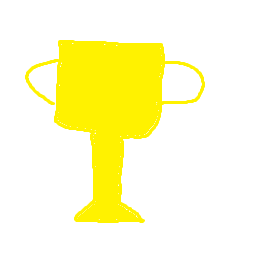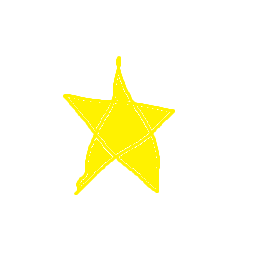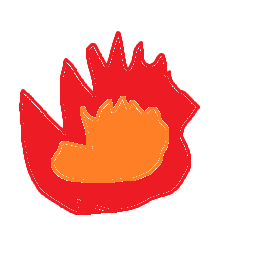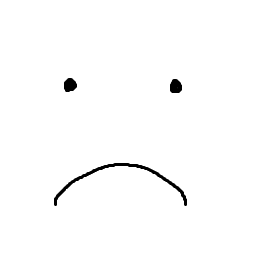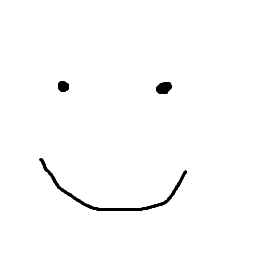

Ух ты! Работает

In [33]:
def clip_cosine_similarity(image_path: str, text: str) -> float:
    model.eval()
    with torch.no_grad():
        image = Image.open(image_path).convert("RGB")
        image_input = preprocess(image).unsqueeze(0).to(device)
        text_tokens = tokenizer([text]).to(device)

        image_features = model.encode_image(image_input)
        text_features = model.encode_text(text_tokens)

        image_features = torch.nn.functional.normalize(image_features, dim=-1)
        text_features = torch.nn.functional.normalize(text_features, dim=-1)

        cosine_sim = (image_features @ text_features.T).item()

    return cosine_sim

In [34]:
descriptions = [
    ":smiling_face:",
    ":blue_t_shirt:",
    ":t_shirt:",
    ":jeans:",
    ":pants:",
    ":red_t_shirt:"
]

image_path = "/content/t-shirt.png"

results = []

for text in descriptions:
    score = clip_cosine_similarity(image_path, text)
    results.append((text, score))

results.sort(key=lambda x: x[1], reverse=True)

for text, score in results:
    print(f"{text:20s} -> {score:.4f}")

:blue_t_shirt:       -> 0.3167
:t_shirt:            -> 0.3019
:red_t_shirt:        -> 0.2865
:pants:              -> 0.2385
:jeans:              -> 0.2367
:smiling_face:       -> 0.1433


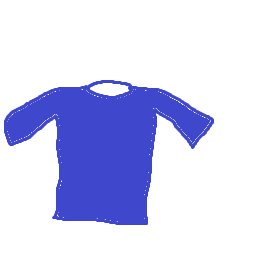

In [37]:
top_probs, top_idx = predict_topk("/content/t-shirt.png", TOPK)
print(f"\n=== t-shirt.png ===")
for r, (cos, idx) in enumerate(zip(top_probs.tolist(), top_idx.tolist()), start=1):
    row = df.iloc[idx]
    print(f"{r:02d}. cos_sim={cos:.4f}  {row['Emoji Name']}  {row.get('Emoji Character','')}")


=== t-shirt.png ===
01. cos_sim=0.9433  :running_shirt:  🎽
02. cos_sim=0.0223  :woman’s_clothes:  👚
03. cos_sim=0.0185  :t-shirt:  👕
04. cos_sim=0.0042  :club_suit:  ♣️
05. cos_sim=0.0042  :club_suit:  ♣


Вот кстати как выглядело :t-shirt: в датасете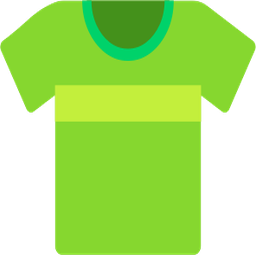

Мне очень сложно было найти смайлик, похожих, на который не было в датасете. Поэтому выбрал такой:

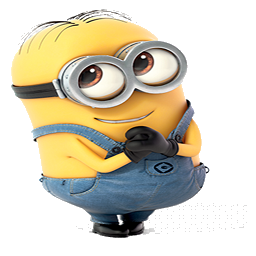

In [56]:
descriptions = [
    ":minion:",
    ":banana:",
    ":glasses:",
    ":jeans:",
    ":smiling_face:"
]

image_path = "/content/minion.png"

results = []

for text in descriptions:
    score = clip_cosine_similarity(image_path, text)
    results.append((text, score))

results.sort(key=lambda x: x[1], reverse=True)

for text, score in results:
    print(f"{text:20s} -> {score:.4f}")

:minion:             -> 0.3294
:banana:             -> 0.2049
:smiling_face:       -> 0.1763
:jeans:              -> 0.1696
:glasses:            -> 0.1693


In [57]:
top_probs, top_idx = predict_topk("/content/minion.png", TOPK)
print(f"\n=== minion.png ===")
for r, (cos, idx) in enumerate(zip(top_probs.tolist(), top_idx.tolist()), start=1):
    row = df.iloc[idx]
    print(f"{r:02d}. cos_sim={cos:.4f}  {row['Emoji Name']}  {row.get('Emoji Character','')}")


=== minion.png ===
01. cos_sim=0.1972  :Gabon:  🇬🇦
02. cos_sim=0.0635  :owl:  🦉
03. cos_sim=0.0473  :cyclone:  🌀
04. cos_sim=0.0375  :baby_symbol:  🚼
05. cos_sim=0.0206  :fish:  🐟
